In [1]:
#importing necessary libraries

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#loading the Dataset

file_path = 'C:\\Users\\krishna\\Downloads\\Recommendation'
stock_data = pd.read_excel("datasets/Recommendation.xlsx")

In [3]:
stock_data.head()

,Company Name,Symbol,Industry,Series,Open,High,Low,Previous Close,Last Traded Price,Change,Percentage Change,Share Volume,Value (Indian Rupee),52 Week High,52 Week Low,365 Day Percentage Change,30 Day Percentage Change
0,3M India Ltd.,3MINDIA,Diversified,EQ,21950.00,21999.00,21126.05,21854.05,21575.00,-279.05,-1.28,4159,8.965357e+07,27800.00,17273.00,-10.18,8.22
1,Aarti Drugs Ltd.,AARTIDRUGS,Healthcare,EQ,400.50,401.80,394.10,403.85,400.00,-3.85,-0.95,31782,1.262731e+07,749.75,378.00,-42.92,-5.1
2,Aavas Financiers Ltd.,AAVAS,Financial Services,EQ,1997.10,2004.05,1894.50,2015.45,1943.15,-72.3,-3.59,150704,2.907728e+08,3340.00,1815.00,-25.69,-9.39
3,ABB India Ltd.,ABB,Capital Goods,EQ,2260.35,2311.50,2260.35,2300.90,2280.00,-20.9,-0.91,97053,2.210935e+08,2487.85,1618.05,27.25,-5.21
4,Abbott India Ltd.,ABBOTINDIA,Healthcare,EQ,18700.40,19200.00,18605.00,18760.40,19199.80,439.4,2.34,12396,2.346770e+08,23934.45,15514.00,11.61,5.84


In [4]:
#selecting relevant columns for recommendation

features = stock_data[['Company Name','Symbol', 'Industry','Last Traded Price', '365 Day Percentage Change']]

In [5]:
filter = features['Company Name']== 'Gujarat Fluorochemicals Ltd.'
 
# filtering data
filter

0      False
1      False
2      False
3      False
4      False
       ...  
496    False
497    False
498    False
499    False
500    False
Name: Company Name, Length: 501, dtype: bool

In [6]:
#Drop rows with missing values

features = features.dropna()

In [7]:
#convert numeric features to string for TF-IDF vectorization

features['Last Traded Price'] = features['Last Traded Price'].astype(str)
features['365 Day Percentage Change'] = features['365 Day Percentage Change'].astype(str)

In [8]:
#Combine all features into a single column for TF-IDF vectorization

features['combined_features'] = features.apply(lambda row: ' '.join(row), axis=1)

In [9]:
#TF-IDF vectorization

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(features['combined_features'])

In [10]:
#computing cosine similarity matrix

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [12]:
#Function to get the top N similar compaines for a given stock

def get_top_companies(stock_name, cosine_sim=cosine_sim, top_n=3):
    idx = features.index[features['Company Name'] == stock_name].tolist()[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:(top_n+1)]
    stock_indices = [i[0] for i in sim_scores]
    recommendations = features.iloc[stock_indices][['Company Name', 'Symbol', 'Last Traded Price', '365 Day Percentage Change']]
    return recommendations

In [13]:
#Get top 3 companies similar to a given stock

stock_to_recommend = 'Gujarat Fluorochemicals Ltd.'
top_companies = get_top_companies(stock_to_recommend, top_n=3)

In [14]:
#print the output

print(f"Highest 3 companies similar to {stock_to_recommend} based on features: ")
print(top_companies)

Highest 3 companies similar to Gujarat Fluorochemicals Ltd. based on features: 
                                          Company Name     Symbol  \
178    Gujarat Alkalies & Chemicals in Vadodara, India  GUJALKALI   
176  Gujarat State Fertilizers & Chemicals in Vadod...       GSFC   
163  Gujarat Narmada Valley Fertilizers and Chemica...       GNFC   

    Last Traded Price 365 Day Percentage Change  
178             689.0                     71.35  
176             130.6                     14.09  
163             580.5                     51.59  


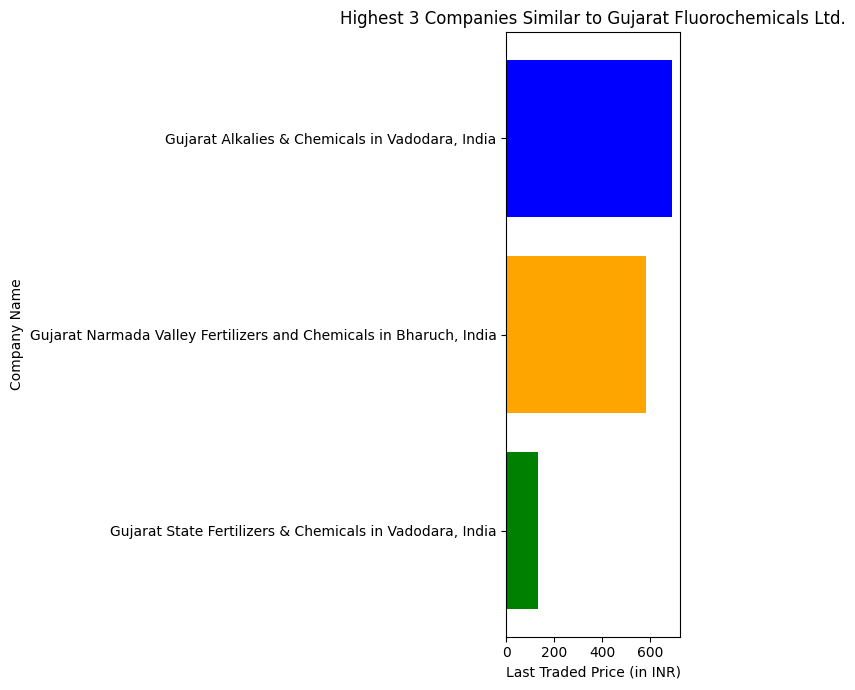

In [27]:
#highest 3 companies similar to Gujarat fluorochemicals ltd. 
#plt.figure(figsize=(10, 3))
#plt.barh(top_companies['Company Name'], top_companies['Last Traded Price'], color='lightgreen', edgecolor='black')
y = np.array([689.0, 130.6, 580.5])
company_names = top_companies['Company Name']  # Replace with top_companies['Company Name']

# Sort the data in descending order for better visual representation
sorted_indices = np.argsort(y)[::-1]
y_sorted = y[sorted_indices]
company_names_sorted = np.array(company_names)[sorted_indices]

plt.figure(figsize=(7,7))  # Adjust figure size as needed
plt.barh(company_names_sorted, y_sorted, color=['blue', 'orange', 'green'])
plt.xlabel('Last Traded Price (in INR)')
plt.ylabel('Company Name')
plt.title(f'Highest 3 Companies Similar to {stock_to_recommend}')
plt.gca().invert_yaxis()  # Invert y-axis to show highest price at the top
plt.tight_layout()  # Adjust layout to prevent overlapping labels
plt.show()

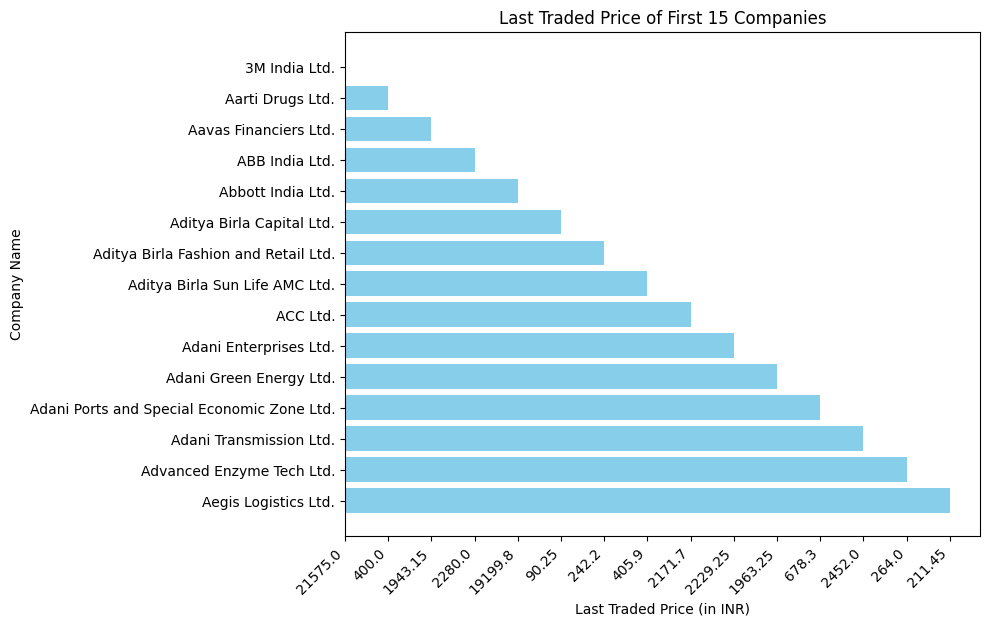

In [53]:
#last traded price of all companies

plt.figure(figsize=(10, 6))
bars = plt.barh(features['Company Name'][:15], features['Last Traded Price'][:15], color='skyblue')
plt.xlabel('Last Traded Price (in INR)')
plt.ylabel('Company Name')
plt.title('Last Traded Price of First 15 Companies')
plt.gca().invert_yaxis()  # Invert y-axis to show highest price at the top
plt.tight_layout()  # Adjust layout to prevent overlapping labels
plt.xticks(rotation=45, ha='right')
plt.show()   